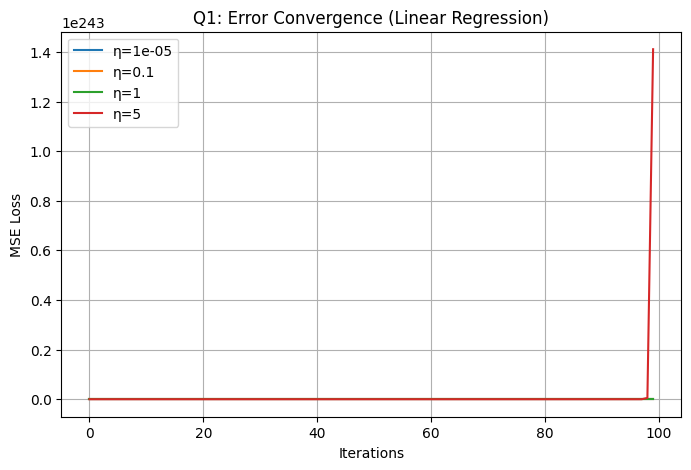

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([
    [0.68, -0.22],
    [1.12, 0.46],
    [-0.18, 0.42],
    [-0.51, -0.49],
    [0.91, -2.1],
    [-1.5, -1.77],
    [0.77, 0.51],
    [-0.62, -1.61],
    [-1.32, -0.84],
    [0.57, 0.48]
])

y = np.array([4.7, 7.61, 4.9, 1.52, -0.5, -4.3, 7.06, -2.06, -1.16, 6.59])

# Add bias
m = len(y)
X_b = np.c_[np.ones((m, 1)), X]

# Cost function
def compute_cost(X, y, theta):
    return (1/m) * np.sum((X @ theta - y) ** 2)

# Gradient Descent
def gradient_descent(X, y, lr, iterations):
    theta = np.zeros(X.shape[1])
    costs = []

    for _ in range(iterations):
        gradients = (2/m) * X.T @ (X @ theta - y)
        theta -= lr * gradients
        costs.append(compute_cost(X, y, theta))

    return theta, costs


learning_rates = [0.00001, 0.1, 1, 5]

plt.figure(figsize=(8,5))

for lr in learning_rates:
    theta, costs = gradient_descent(X_b, y, lr, 100)
    plt.plot(costs, label=f"η={lr}")

plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Q1: Error Convergence (Linear Regression)")
plt.legend()
plt.grid()
plt.show()

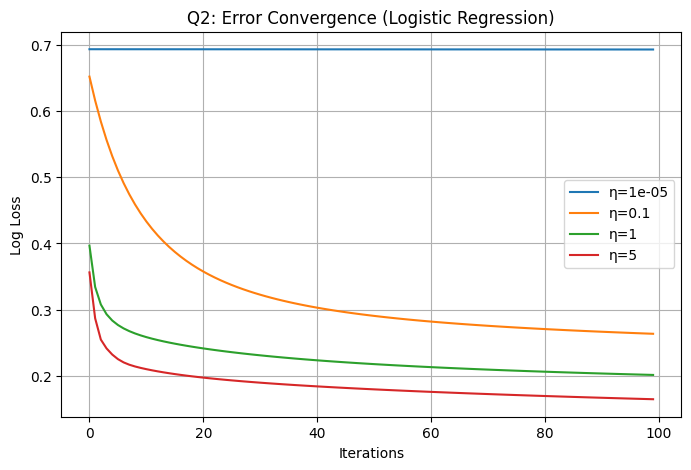

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([
    [1.07, -0.97],
    [-1.14, -0.84],
    [-2.9, 1.98],
    [-0.72, -0.96],
    [-1.96, -0.99],
    [-0.94, -0.54],
    [1.73, -1.19],
    [1.78, 1.51],
    [1.9, 0.83],
    [-0.59, -1.97]
])

y = np.array([1,0,0,0,0,1,1,1,1,0])

m = len(y)

# Add bias
X_b = np.c_[np.ones((m, 1)), X]

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Cost function (Log Loss)
def compute_cost(X, y, theta):
    h = sigmoid(X @ theta)
    return -(1/m) * np.sum(y*np.log(h + 1e-9) + (1-y)*np.log(1-h + 1e-9))

# Gradient Descent
def gradient_descent(X, y, lr, iterations):
    theta = np.zeros(X.shape[1])
    costs = []

    for _ in range(iterations):
        h = sigmoid(X @ theta)
        gradients = (1/m) * X.T @ (h - y)
        theta -= lr * gradients
        costs.append(compute_cost(X, y, theta))

    return theta, costs


learning_rates = [0.00001, 0.1, 1, 5]

plt.figure(figsize=(8,5))

for lr in learning_rates:
    theta, costs = gradient_descent(X_b, y, lr, 100)
    plt.plot(costs, label=f"η={lr}")

plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Q2: Error Convergence (Logistic Regression)")
plt.legend()
plt.grid()
plt.show()

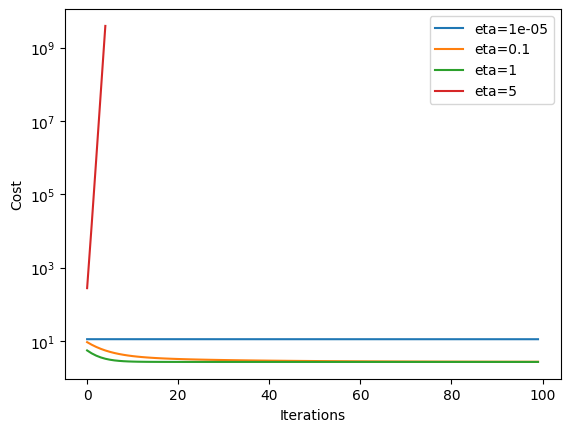

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x1 = np.array([0.68,1.12,-0.18,-0.51,0.91,-1.5,0.77,-0.62,-1.32,0.57])
x2 = np.array([-0.22,0.46,0.42,-0.49,2.1,-1.77,0.51,-1.61,-0.84,0.48])
y = np.array([4.7,7.61,4.9,1.52,0.5,-4.3,7.06,-2.06,-1.16,6.59])

m = len(y)
X = np.column_stack((np.ones(m), x1, x2))

def compute_cost(X, y, theta):
    return (1/(2*m)) * np.sum((X @ theta - y)**2)

def gradient_descent(X, y, theta, alpha, iterations):
    cost_history = []
    for _ in range(iterations):
        theta = theta - (alpha/m) * (X.T @ (X @ theta - y))
        cost = compute_cost(X, y, theta)
        if np.isnan(cost) or cost > 1e10:
            break
        cost_history.append(cost)
    return theta, cost_history

etas = [0.00001, 0.1, 1, 5]
iterations = 100

for eta in etas:
    theta = np.zeros(3)
    theta, cost_history = gradient_descent(X, y, theta, eta, iterations)
    plt.plot(cost_history, label=f'eta={eta}')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.yscale('log')
plt.legend()
plt.show()